# 260414-1: CNN Fundamentals — Convolution, Padding, Pooling

이번 실습에서는 **CNN의 핵심 연산**을 작은 예제부터 직접 구현합니다.  
강의에서 다룬 **local connectivity**, **parameter sharing**, **stride/padding**, **pooling**이 실제 코드에서 어떤 계산과 변화로 나타나는지 확인합니다.

## 학습 목표
- Conv/Pool layer의 출력 크기 공식을 직접 구현한다.
- `numpy`로 convolution forward pass를 구현한다.
- filter가 feature map을 만드는 과정을 시각화하여 확인한다.
- max pooling이 spatial down-sampling을 수행하는 방식을 구현한다.
- Fully-connected layer와 convolution layer의 parameter 수 차이를 비교한다.

## 구성
| 순서 | 내용 | 핵심 질문 |
|---|---|---|
| 1 | Conv output size | stride와 padding이 출력 크기를 어떻게 바꾸는가? |
| 2 | Naive convolution forward | convolutional filter는 입력 위를 어떻게 sliding하는가? |
| 3 | Filter visualization | human designed edge/blur filter는 어떤 feature map을 만드는가? |
| 4 | Max pooling | pooling은 어떤 정보를 남기고 어떤 정보를 버리는가? |
| 5 | Parameter sharing | CNN은 왜 이미지에서 MLP보다 parameter 효율적인가? |

## 이론 설명

### 핵심 개념 정리
CNN은 이미지처럼 grid topology를 가진 데이터에 맞춰 설계된 neural network입니다. MLP처럼 모든 pixel을 모든 neuron에 연결하지 않고, 작은 receptive field를 보는 filter를 전체 위치에 공유해서 적용합니다.

| 개념 | 의미 | 코드에서 확인할 위치 |
|---|---|---|
| Local connectivity | 각 neuron이 입력의 작은 영역만 봄 | `window = x_pad[..., h0:h1, w0:w1]` |
| Parameter sharing | 같은 filter를 모든 위치에 적용 | `w[f]`를 모든 `(i, j)`에 재사용 |
| Stride | filter 이동 간격 | `h0 = i * stride`, `w0 = j * stride` |
| Padding | 입력 가장자리에 0을 추가 | `np.pad(...)` |
| Pooling | spatial 크기를 줄이고 강한 반응을 남김 | `np.max(window)` |

### Notation 안내

CNN 수식과 PyTorch 코드에 대해 이 노트북에서는 다음 대응을 계속 사용합니다.

| 수식/강의 표현 | 코드 표현 | 설명 |
|---|---|---|
| input volume | `x` | batch를 포함하면 `(N, C, H, W)` |
| convolutional  filter/kernel | `w` | `(F, C, HH, WW)`이며 `F`가 output channel 수 |
| bias | `b` | filter마다 하나씩 있으므로 `(F,)` |
| stride | `stride` | window가 한 번에 이동하는 pixel 수 |
| zero-padding | `pad` | 입력 가장자리에 0을 덧붙이는 폭 |
| feature map / activation map | `out[:, f, :, :]` | 특정 filter가 전체 위치에서 만든 반응 |

코드를 읽을 때는 항상 “지금 보고 있는 축이 batch인지, channel인지, spatial인지”를 먼저 확인하세요. CNN 버그의 상당수는 값 자체보다 축 해석에서 시작됩니다.

## 코드 실습

이제 이론에서 정리한 개념을 코드로 확인합니다. 첫 두 셀은 환경 설정과 공통 import입니다. 이후 각 섹션은 `설명 -> 구현 -> 검증 -> 관찰` 순서로 진행됩니다.

검증 셀에서 `OK`가 출력되면 다음 단계로 넘어가면 됩니다. 오류가 나면 shape, padding, stride index를 우선 확인하세요.

### 실행 안내

아래 두 셀은 환경 확인과 공통 라이브러리 import입니다.

- Colab에서 실행하면 GPU가 보이는지 확인합니다. 이번 첫 번째 노트북은 대부분 CPU로도 충분합니다.
- `np.random.seed`, `torch.manual_seed`는 같은 결과를 재현하기 위한 장치입니다.
- `rel_error`는 우리가 직접 구현한 numpy 결과와 PyTorch 기준 결과가 얼마나 가까운지 비교할 때 사용합니다.

In [ ]:
# Colab / local environment check
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available')
        print(gpu_info.stdout.split('\n')[0])
    else:
        print('GPU is not available. Runtime > Change runtime type > GPU 를 선택하세요.')
else:
    print('Running outside Colab')


GPU available
Mon Apr 13 02:39:01 2026       


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['axes.grid'] = False

np.random.seed(42)
torch.manual_seed(42)

def rel_error(x, y):
    return np.max(np.abs(x - y) / np.maximum(1e-8, np.abs(x) + np.abs(y)))


## 1. Conv Output Size

강의에서 다룬 convolution의 spatial 출력 크기는 다음 식으로 계산됩니다.

$$
H_{out} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1
$$

여기서 $H$는 입력 크기, $P$는 padding, $K$는 kernel/filter 크기, $S$는 stride입니다.

### 구현 안내

이 함수는 convolution과 pooling에서 공통으로 쓰입니다. 한 축에 대해서만 계산하므로 height와 width에 각각 같은 함수를 적용하면 됩니다.

계산 순서는 다음과 같습니다.

1. 입력 양쪽에 padding이 붙으면 유효한 길이는 `input_size + 2 * padding`이 됩니다.
2. 그 위에 `kernel_size`짜리 window를 올릴 수 있는 시작 위치를 셉니다.
3. stride만큼 건너뛰므로 전체 이동 가능 거리를 `stride`로 나눕니다.
4. 시작 위치 0도 하나의 출력이므로 마지막에 `+ 1`을 더합니다.

주의할 점은 Python에서 정수 나눗셈 `//`을 사용해야 한다는 것입니다. 강의 수식의 floor와 같은 역할입니다.

In [ ]:
def conv_output_size(input_size, kernel_size, stride=1, padding=0):
    """
    Conv/Pool layer의 한 축 출력 크기를 계산하세요.

    Formula:
        out = floor((input + 2*padding - kernel) / stride) + 1
    """
    out = (input_size + 2 * padding - kernel_size) // stride + 1
    return out


### 검증 안내

검증 셀은 여러 조합의 `(input, kernel, stride, padding)`을 넣어 예상 출력 크기와 비교합니다.

특히 다음 두 케이스를 눈여겨보세요.

- `7x7`, `3x3`, stride 1, padding 0이면 출력은 `5x5`입니다.
- 같은 조건에서 padding 1을 주면 출력이 다시 `7x7`이 됩니다. 이것이 강의에서 말한 spatial size 보존입니다.

In [ ]:
# Output size verification
cases = [
    (7, 3, 1, 0, 5),
    (7, 3, 2, 0, 3),
    (7, 3, 1, 1, 7),
    (32, 5, 1, 2, 32),
    (32, 3, 2, 1, 16),
]

for input_size, kernel_size, stride, padding, expected in cases:
    got = conv_output_size(input_size, kernel_size, stride, padding)
    print((input_size, kernel_size, stride, padding), '->', got)
    assert got == expected, f'expected {expected}, got {got}'

print('Output size formula: OK')


(7, 3, 1, 0) -> 5
(7, 3, 2, 0) -> 3
(7, 3, 1, 1) -> 7
(32, 5, 1, 2) -> 32
(32, 3, 2, 1) -> 16
Output size formula: OK


### 시각화: 왜 7x7 입력과 3x3 kernel의 출력은 5x5일까?

수식으로는 `(7 - 3) / 1 + 1 = 5`라서 출력 한 축의 크기가 5가 됩니다. 하지만 처음 볼 때는 이 `+1`이 잘 와닿지 않을 수 있습니다.

아래 그림은 같은 내용을 grid로 보여줍니다.

- 왼쪽 7x7 grid는 입력입니다.
- 파란색 cell은 3x3 kernel의 **왼쪽 위 모서리**가 놓일 수 있는 위치입니다.
- 주황색 3x3 영역은 선택된 kernel window입니다.
- 오른쪽 5x5 grid는 출력 feature map입니다.
- 출력의 cell 하나는 입력에서 kernel window 하나를 계산한 결과와 대응됩니다.

즉, 7x7 입력 위에서 3x3 kernel의 시작 위치는 행 방향 5개, 열 방향 5개입니다. 그래서 출력이 5x5가 됩니다.

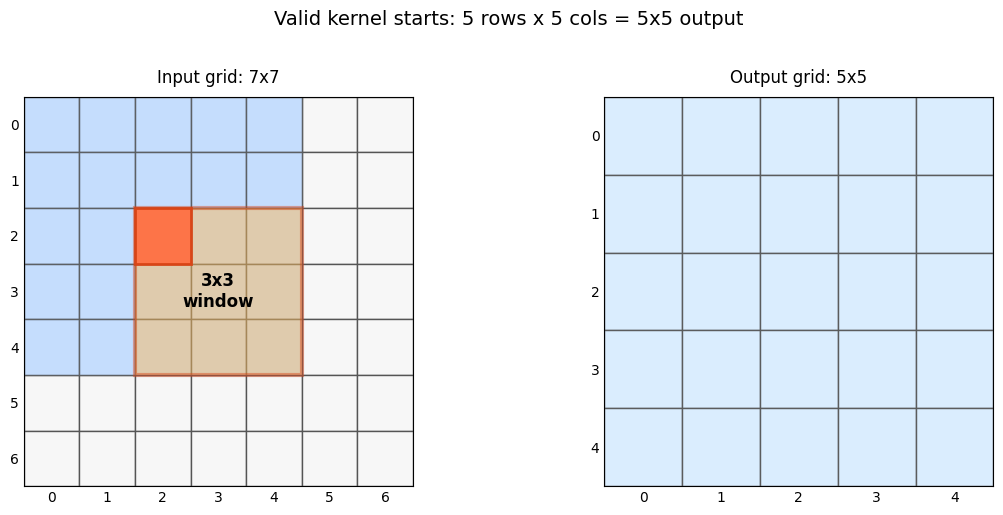

In [ ]:
# Visualize why 7x7 input with 3x3 kernel produces 5x5 output
from matplotlib.patches import Rectangle


def draw_grid(ax, n_rows, n_cols, title, base_color='#f7f7f7'):
    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_xticklabels(range(n_cols))
    ax.set_yticklabels(range(n_rows))
    ax.tick_params(length=0)
    for r in range(n_rows):
        for c in range(n_cols):
            ax.add_patch(Rectangle((c, r), 1, 1, facecolor=base_color, edgecolor='#555555', linewidth=1.0))


def visualize_kernel_positions(input_size=7, kernel_size=3, stride=1, padding=0, selected_output=(2, 2)):
    output_size = conv_output_size(input_size, kernel_size, stride, padding)
    out_r, out_c = selected_output
    start_r = out_r * stride
    start_c = out_c * stride

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax_in, ax_out = axes

    draw_grid(ax_in, input_size, input_size, f'Input grid: {input_size}x{input_size}')
    draw_grid(ax_out, output_size, output_size, f'Output grid: {output_size}x{output_size}')

    # Valid top-left positions of the kernel on the input grid.
    for r in range(output_size):
        for c in range(output_size):
            top = r * stride
            left = c * stride
            ax_in.add_patch(Rectangle((left, top), 1, 1, facecolor='#b9d7ff', edgecolor='#555555', alpha=0.8))
            ax_out.add_patch(Rectangle((c, r), 1, 1, facecolor='#d7ecff', edgecolor='#555555', alpha=0.9))

    # Selected 3x3 receptive field and matching output cell.
    ax_in.add_patch(Rectangle((start_c, start_r), kernel_size, kernel_size,
                              facecolor='#ffb74d', edgecolor='#d84315', linewidth=3, alpha=0.45))
    ax_in.add_patch(Rectangle((start_c, start_r), 1, 1,
                              facecolor='#ff7043', edgecolor='#d84315', linewidth=2, alpha=0.95))
    ax_in.text(start_c + kernel_size / 2, start_r + kernel_size / 2,
               f'{kernel_size}x{kernel_size}\nwindow', ha='center', va='center', fontsize=12, weight='bold')

    fig.suptitle(
        f'Valid kernel starts: {output_size} rows x {output_size} cols = {output_size}x{output_size} output',
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


visualize_kernel_positions(input_size=7, kernel_size=3, stride=1, padding=0, selected_output=(2, 2))


## 2. Naive Convolution Forward

Convolution layer는 작은 filter를 입력 위로 sliding하면서 feature map을 만듭니다.  
이번에는 효율성보다 원리 이해가 목적이므로 4중 loop로 구현합니다.

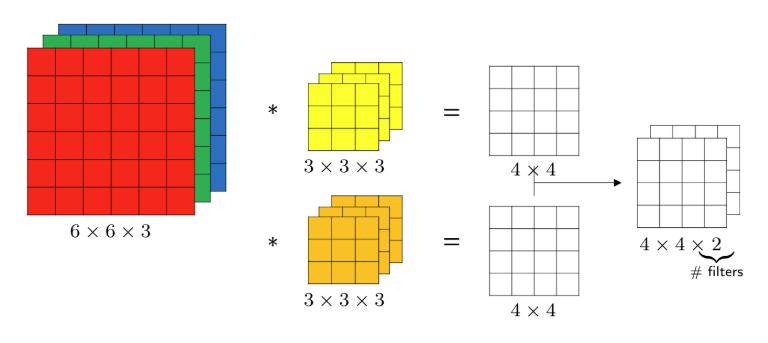

### 구현 안내

`conv_forward_naive`는 CNN의 가장 중요한 연산인 convolution을 구현합니다. 입력과 filter의 shape은 다음처럼 읽습니다.

| Symbol | 의미 |
|---|---|
| `N` | batch size |
| `C` | input channel 수, RGB 이미지는 3 |
| `H, W` | input height, width |
| `F` | filter 개수, 즉 output channel 수 |
| `HH, WW` | filter의 spatial height, width |

각 출력 위치 `out[n, f, i, j]`는 `x_pad[n]`에서 window 하나를 잘라 `w[f]`와 element-wise 곱한 뒤 모두 더하고 bias `b[f]`를 더한 값입니다.

구현할 때는 `i`, `j`가 output 좌표라는 점을 기억하세요. input에서 실제 시작 위치는 `i * stride`, `j * stride`입니다.

In [ ]:
def conv_forward_naive(x, w, b, conv_param):
    """
    Naive convolution forward pass.

    Args:
        x: input, shape (N, C, H, W)
        w: filters, shape (F, C, HH, WW)
        b: bias, shape (F,)
        conv_param: {'stride': int, 'pad': int}

    Returns:
        out: shape (N, F, H_out, W_out)
        cache: values needed for backward or debugging
    """
    stride = conv_param.get('stride', 1)
    pad = conv_param.get('pad', 0)
    N, C, H, W = x.shape
    F, _, HH, WW = w.shape

    H_out = conv_output_size(H, HH, stride, pad)
    W_out = conv_output_size(W, WW, stride, pad)
    out = np.zeros((N, F, H_out, W_out), dtype=x.dtype)

    x_pad = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='constant')

    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                h0 = i * stride
                h1 = h0 + HH
                for j in range(W_out):
                    w0 = j * stride
                    w1 = w0 + WW
                    window = x_pad[n, :, h0:h1, w0:w1]
                    out[n, f, i, j] = np.sum(window * w[f]) + b[f]

    cache = (x, w, b, conv_param, x_pad)
    return out, cache


### 검증 안내

우리가 구현한 convolution 결과를 PyTorch의 `F.conv2d`와 비교합니다. PyTorch는 이미 최적화된 정답 함수라고 생각하면 됩니다.

`relative error`가 매우 작으면 계산이 맞았다는 뜻입니다. 완전히 0이 아닌 이유는 `float32` 연산에서 누적 순서가 조금 달라질 수 있기 때문입니다.

In [ ]:
# Convolution verification against PyTorch
np.random.seed(231)
x = np.random.randn(2, 3, 5, 5).astype(np.float32)
w = np.random.randn(4, 3, 3, 3).astype(np.float32)
b = np.random.randn(4).astype(np.float32)
conv_param = {'stride': 2, 'pad': 1}

out_np, _ = conv_forward_naive(x, w, b, conv_param)
out_torch = F.conv2d(
    torch.tensor(x),
    torch.tensor(w),
    torch.tensor(b),
    stride=conv_param['stride'],
    padding=conv_param['pad'],
).numpy()

print('out shape:', out_np.shape)
print('relative error:', rel_error(out_np, out_torch))
assert rel_error(out_np, out_torch) < 1e-5
print('conv_forward_naive: OK')


out shape: (2, 4, 3, 3)
relative error: 4.877137e-07
conv_forward_naive: OK


## 3. Filters as Feature Detectors

강의에서는 CNN filter가 edge, color blob 같은 시각 feature에 반응한다고 설명했습니다.  
아래에서는 학습된 filter 대신 사람이 만든 Sobel/blur filter로 feature map이 어떻게 생기는지 관찰합니다.

### 관찰 포인트

여기서는 학습된 CNN filter 대신 직접 만든 filter를 사용합니다. 이렇게 하면 filter가 어떤 시각 패턴에 반응하는지 더 직관적으로 볼 수 있습니다.

- `vertical edge`: 좌우 밝기 차이에 크게 반응합니다.
- `horizontal edge`: 상하 밝기 차이에 크게 반응합니다.
- `blur`: 주변 픽셀 평균을 내므로 이미지를 부드럽게 만듭니다.

실제 CNN의 첫 layer filter도 학습 초기에 이런 edge/color detector와 비슷한 패턴을 배우는 경우가 많습니다.

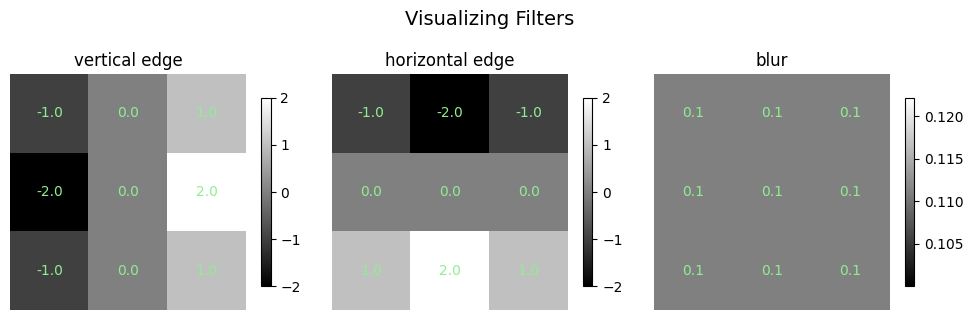

In [ ]:
fig, axes = plt.subplots(1, len(filters), figsize=(10, 3))

for ax, name, f_data in zip(axes, filters.keys(), filters.values()):
    im = ax.imshow(f_data, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
    # Add colorbar for better visualization of filter values
    plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8)

    # Add numerical values to the plot
    for i in range(f_data.shape[0]):
        for j in range(f_data.shape[1]):
            text = ax.text(j, i, f'{f_data[i, j]:.1f}',
                           ha='center', va='center', color='lightgreen', fontsize=10) # Changed color to 'skyblue'

plt.suptitle('Visualizing Filters', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

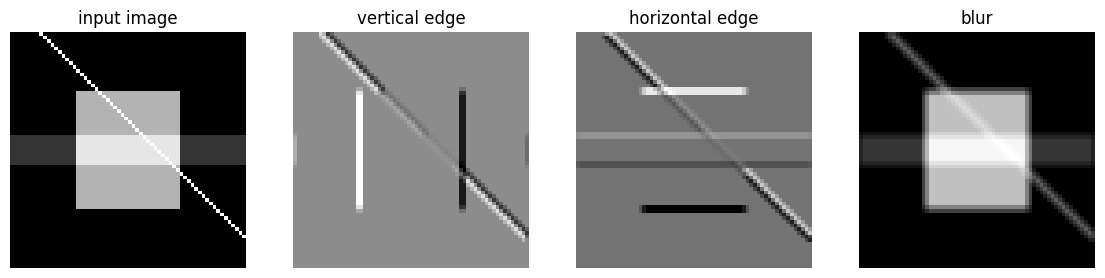

In [ ]:
# Synthetic image: square + diagonal line
img = np.zeros((64, 64), dtype=np.float32)
img[16:48, 18:46] = 0.7
np.fill_diagonal(img[:, 8:72], 1.0)
img[28:36, :] += 0.2
img = np.clip(img, 0, 1)

filters = {
    'vertical edge': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32),
    'horizontal edge': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32),
    'blur': np.ones((3, 3), dtype=np.float32) / 9.0,
}

x_img = img[None, None, :, :]
w_filters = np.stack([f for f in filters.values()])[:, None, :, :]
b_filters = np.zeros(len(filters), dtype=np.float32)
feature_maps, _ = conv_forward_naive(x_img, w_filters, b_filters, {'stride': 1, 'pad': 1})

fig, axes = plt.subplots(1, 1 + len(filters), figsize=(14, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('input image')
axes[0].axis('off')

for ax, name, fmap in zip(axes[1:], filters.keys(), feature_maps[0]):
    ax.imshow(fmap, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.show()


## 4. Max Pooling

Pooling layer는 각 depth slice마다 독립적으로 동작하며 spatial 크기를 줄입니다.  
2x2 max pooling with stride 2는 activation의 75%를 버리지만, 강한 반응의 위치 정보를 남깁니다.

### 구현 안내

Max pooling은 convolution과 비슷하게 window를 움직이지만, filter와 곱하지 않습니다. window 안의 값 중 가장 큰 값만 출력으로 보냅니다.

중요한 차이는 channel 처리입니다. Pooling은 각 channel을 독립적으로 처리하므로 channel 수 `C`는 변하지 않습니다. 예를 들어 입력이 `(N, 64, 32, 32)`이고 2x2 stride 2 pooling을 적용하면 출력은 `(N, 64, 16, 16)`입니다.

In [ ]:
def max_pool_forward_naive(x, pool_param):
    """
    Max pooling forward pass.

    Args:
        x: input, shape (N, C, H, W)
        pool_param: {'pool_height': int, 'pool_width': int, 'stride': int}
    """
    N, C, H, W = x.shape
    PH = pool_param['pool_height']
    PW = pool_param['pool_width']
    stride = pool_param['stride']
    H_out = conv_output_size(H, PH, stride, padding=0)
    W_out = conv_output_size(W, PW, stride, padding=0)
    out = np.zeros((N, C, H_out, W_out), dtype=x.dtype)

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                h0 = i * stride
                h1 = h0 + PH
                for j in range(W_out):
                    w0 = j * stride
                    w1 = w0 + PW
                    out[n, c, i, j] = np.max(x[n, c, h0:h1, w0:w1])
    return out


### 시각화

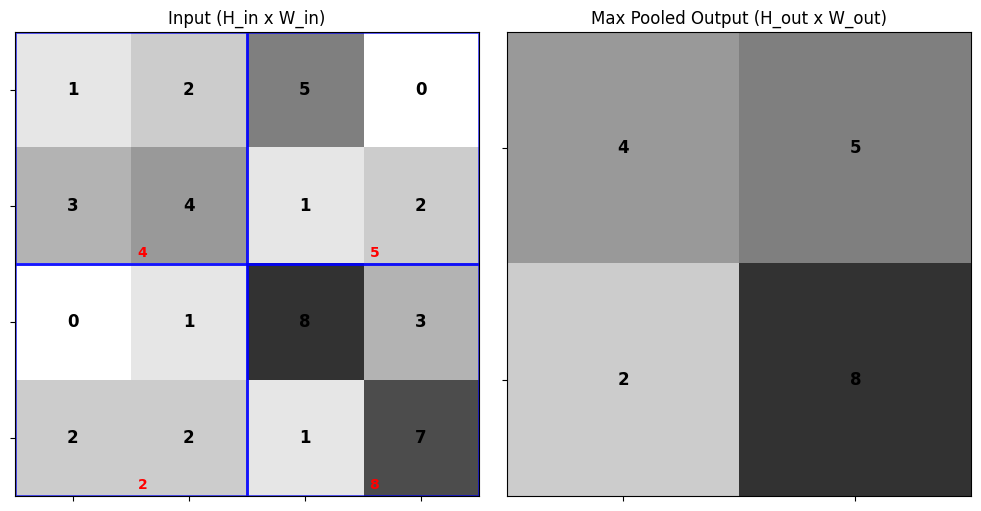

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_max_pooling(x_input, pool_param):
    PH = pool_param['pool_height']
    PW = pool_param['pool_width']
    stride = pool_param['stride']

    # Calculate output using the previously defined function
    out_pool = max_pool_forward_naive(x_input[None, None, :, :], pool_param)[0, 0]

    H, W = x_input.shape
    H_out, W_out = out_pool.shape

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    ax_input, ax_output = axes

    # Visualize Input
    ax_input.imshow(x_input, cmap='gray_r', origin='upper', vmin=0, vmax=np.max(x_input) + 2)
    ax_input.set_title('Input (H_in x W_in)')
    ax_input.set_xticks(np.arange(W))
    ax_input.set_yticks(np.arange(H))
    ax_input.set_xticklabels([])
    ax_input.set_yticklabels([])
    # ax_input.grid(color='black', linestyle='-', linewidth=1) # Removed grid

    # Add numerical values to input
    for r in range(H):
        for c in range(W):
            ax_input.text(c, r, f'{x_input[r, c]:.0f}',
                           ha='center', va='center', color='black', fontsize=12, weight='bold')

    # Highlight pooling windows on input
    for i in range(H_out):
        h0 = i * stride
        for j in range(W_out):
            w0 = j * stride
            rect = plt.Rectangle((w0 - 0.5, h0 - 0.5), PW, PH, fill=False, edgecolor='blue', linewidth=2, alpha=0.7)
            ax_input.add_patch(rect)
            # Add max value from window to visualize
            window = x_input[h0:h0+PH, w0:w0+PW]
            max_val = np.max(window)
            ax_input.text(w0 + PW/2 - 0.4, h0 + PH/2 + 0.4, f'{max_val:.0f}',
                          ha='center', va='center', color='red', fontsize=10, weight='bold')

    # Visualize Output
    ax_output.imshow(out_pool, cmap='gray_r', origin='upper', vmin=0, vmax=np.max(x_input) + 2)
    ax_output.set_title('Max Pooled Output (H_out x W_out)')
    ax_output.set_xticks(np.arange(W_out))
    ax_output.set_yticks(np.arange(H_out))
    ax_output.set_xticklabels([])
    ax_output.set_yticklabels([])
    # ax_output.grid(color='black', linestyle='-', linewidth=1) # Removed grid

    # Add numerical values to output
    for r in range(H_out):
        for c in range(W_out):
            ax_output.text(c, r, f'{out_pool[r, c]:.0f}',
                           ha='center', va='center', color='black', fontsize=12, weight='bold')

    plt.tight_layout()
    plt.show()

# Example usage:
x_example = np.array([
    [1, 2, 5, 0],
    [3, 4, 1, 2],
    [0, 1, 8, 3],
    [2, 2, 1, 7]
], dtype=np.float32)

pool_params_example = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

visualize_max_pooling(x_example, pool_params_example)


### 검증 안내

작은 4x4 배열에서 2x2 pooling을 손으로 계산해볼 수 있습니다. 왼쪽 위 2x2 block `[1,2;3,4]`의 max는 4이고, 오른쪽 아래 2x2 block `[8,3;1,7]`의 max는 8입니다.

검증이 실패하면 `h0`, `h1`, `w0`, `w1` 범위를 먼저 확인하세요.

In [ ]:
# Max pooling verification
x_pool = np.array([[[[
    1, 2, 5, 0,
    3, 4, 1, 2,
    0, 1, 8, 3,
    2, 2, 1, 7,
]]]], dtype=np.float32).reshape(1, 1, 4, 4)

pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}
out_pool = max_pool_forward_naive(x_pool, pool_param)
expected = np.array([[[[4, 5], [2, 8]]]], dtype=np.float32)

print(out_pool)
assert np.array_equal(out_pool, expected)
print('max_pool_forward_naive: OK')


[[[[4. 5.]
   [2. 8.]]]]
max_pool_forward_naive: OK


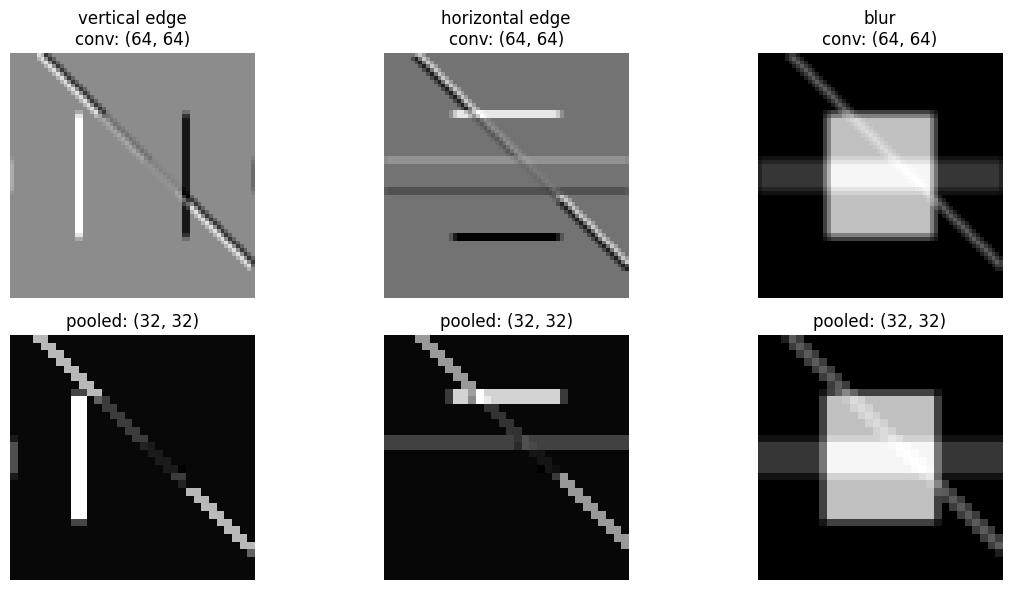

In [ ]:
# Pooling effect on feature maps
pooled = max_pool_forward_naive(feature_maps, {'pool_height': 2, 'pool_width': 2, 'stride': 2})

fig, axes = plt.subplots(2, len(filters), figsize=(12, 6))
for idx, name in enumerate(filters.keys()):
    axes[0, idx].imshow(feature_maps[0, idx], cmap='gray')
    axes[0, idx].set_title(f'{name}\nconv: {feature_maps[0, idx].shape}')
    axes[0, idx].axis('off')

    axes[1, idx].imshow(pooled[0, idx], cmap='gray')
    axes[1, idx].set_title(f'pooled: {pooled[0, idx].shape}')
    axes[1, idx].axis('off')
plt.tight_layout()
plt.show()


### 결과 해석

위쪽 행은 convolution feature map이고, 아래쪽 행은 pooling 이후 결과입니다. pooling 이후에는 이미지가 작아졌지만 강한 edge 반응이 남아 있습니다.

이것이 pooling의 핵심 직관입니다. 위치 정보를 아주 정확하게 유지하기보다, 주변 영역에 어떤 feature가 강하게 존재하는지를 남깁니다.

## 5. Parameter Sharing

MLP는 모든 pixel과 모든 neuron을 연결합니다.  
CNN은 작은 filter를 전체 위치에서 공유하므로 parameter 수가 입력 해상도에 덜 민감합니다.

### 실습 팁

이 셀은 CNN이 왜 이미지에서 MLP보다 효율적인지 숫자로 보여줍니다. Fully-connected layer는 모든 입력 픽셀과 모든 hidden unit을 연결하므로 입력 해상도가 커질수록 parameter 수가 폭발합니다.

반면 convolution은 `kernel_h * kernel_w * input_c * num_filters`만 학습합니다. 같은 filter를 모든 위치에서 공유하기 때문입니다. 이것이 강의의 parameter sharing입니다.

In [ ]:
def fc_params(input_h, input_w, input_c, hidden_units):
    return input_h * input_w * input_c * hidden_units + hidden_units

def conv_params(kernel_h, kernel_w, input_c, num_filters):
    return kernel_h * kernel_w * input_c * num_filters + num_filters

H, W, C = 200, 200, 3
hidden_units = 64
num_filters = 64
kernel = 5

print(f'FC params for one hidden layer ({H}x{W}x{C} -> {hidden_units}): {fc_params(H, W, C, hidden_units):,}')
print(f'Conv params ({kernel}x{kernel}x{C}, {num_filters} filters): {conv_params(kernel, kernel, C, num_filters):,}')
print(f'Parameter reduction: {fc_params(H, W, C, hidden_units) / conv_params(kernel, kernel, C, num_filters):.1f}x')


FC params for one hidden layer (200x200x3 -> 64): 7,680,064
Conv params (5x5x3, 64 filters): 4,864
Parameter reduction: 1579.0x


## Summary

이번 실습에서는 CNN을 구성하는 가장 기본적인 연산을 직접 구현했습니다.

| 개념 | 코드에서 확인한 것 |
|---|---|
| Local connectivity | 작은 receptive field만 사용 |
| Parameter sharing | 같은 filter를 모든 위치에 적용 |
| Stride/Padding | 출력 spatial size 제어 |
| Pooling | depth는 유지하고 spatial size만 축소 |
| Filter interpretation | edge/blur feature map 시각화 |

다음 실습에서는 이 연산들을 PyTorch의 `nn.Conv2d`, `nn.MaxPool2d`로 조립해 CIFAR-10 CNN classifier를 학습합니다.